<a href="https://colab.research.google.com/github/M-TOO/AI_Assignment/blob/main/Copy_of_intelligent_agents_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

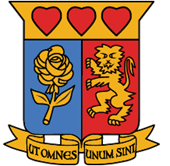

# **Practical 1: Intelligent Agents**
#AIM:
This practical aim to builds a grid-world environment where an Intelligent Cleaning Agent perceives its surroundings, maintains internal state, makes decisions based on goal and utility functions, and acts upon the environment.

#Step 1: Set Up the Environment Class
First, define the environment that the agent interacts with. This grid environment contains dirty cells and obstacles.

In [1]:
# Step 1: Install Required Dependencies
!pip install -q google-genai

In [2]:
import random
import numpy as np

class Environment:
    """
    A 2D Grid World Environment containing clean spots, dirt, and obstacles.
    """
    def __init__(self, width=5, height=5, dirt_prob=0.3, obstacle_prob=0.1):
        self.width = width
        self.height = height
        # State values: 0 = Clean, 1 = Dirty, 2 = Obstacle
        self.grid = np.zeros((height, width), dtype=int)

        # Randomly place dirt and obstacles
        for r in range(height):
            for c in range(width):
                rand = random.random()
                if rand < obstacle_prob:
                    self.grid[r][c] = 2
                elif rand < obstacle_prob + dirt_prob:
                    self.grid[r][c] = 1

        # Ensure starting cell (0,0) is open
        self.grid[0][0] = 0

    def get_percept(self, position):
        """Returns the state of the current cell: 0 (Clean), 1 (Dirty), 2 (Obstacle)."""
        r, c = position
        return self.grid[r][c]

    def is_valid_position(self, position):
        """Checks if the position is within bounds and not an obstacle."""
        r, c = position
        if 0 <= r < self.height and 0 <= c < self.width:
            return self.grid[r][c] != 2
        return False

    def clean_cell(self, position):
        """Action: Cleans the current cell if dirty."""
        r, c = position
        if self.grid[r][c] == 1:
            self.grid[r][c] = 0
            return True
        return False

#Step 2: Implement the Intelligent Agent Class
The agent uses its perceptions, memory (model-based tracking), goals, and utility metrics to decide the best action.

In [3]:
class IntelligentAgent:
    """
    Model-based, Utility-driven Intelligent Agent.
    """
    def __init__(self, start_pos=(0, 0)):
        self.position = start_pos
        self.energy = 100
        self.score = 0
        self.visited_cells = set([start_pos])

    def choose_action(self, percept, env):
        """
        Decision-making process based on Agent Architecture:
        1. Goal/Utility check: If current cell is dirty -> Clean it.
        2. Exploration Strategy: Move to an adjacent valid cell (preferably unvisited).
        """
        # Priority 1: High utility action (Clean dirt)
        if percept == 1:
            return 'CLEAN'

        # Priority 2: Explore adjacent cells
        r, c = self.position
        possible_moves = {
            'UP': (r - 1, c),
            'DOWN': (r + 1, c),
            'LEFT': (r, c - 1),
            'RIGHT': (r, c + 1)
        }

        valid_moves = {dir: pos for dir, pos in possible_moves.items() if env.is_valid_position(pos)}

        if not valid_moves:
            return 'STAY'  # Trapped by obstacles

        # Prefer unvisited cells (Exploration Heuristic)
        unvisited_moves = [dir for dir, pos in valid_moves.items() if pos not in self.visited_cells]

        if unvisited_moves:
            chosen_dir = random.choice(unvisited_moves)
        else:
            chosen_dir = random.choice(list(valid_moves.keys()))

        return chosen_dir

    def execute_action(self, action, env):
        """Updates agent's state and environment based on chosen action."""
        self.energy -= 1  # Movement/action cost

        if action == 'CLEAN':
            if env.clean_cell(self.position):
                self.score += 10
                print(f"Action: CLEAN | Score +10 | Position: {self.position}")
        elif action in ['UP', 'DOWN', 'LEFT', 'RIGHT']:
            r, c = self.position
            moves = {'UP': (r-1, c), 'DOWN': (r+1, c), 'LEFT': (r, c-1), 'RIGHT': (r, c+1)}
            self.position = moves[action]
            self.visited_cells.add(self.position)
            print(f"Action: MOVE {action} -> {self.position}")
        else:
            print(f"Action: STAY at {self.position}")

#Step 3: Run the Perception-Action Loop
Execute the main simulation loop to observe the agent interacting with the environment over several steps.

In [4]:
def run_simulation(steps=15):
    # Initialize Environment and Agent
    env = Environment(width=5, height=5, dirt_prob=0.4, obstacle_prob=0.1)
    agent = IntelligentAgent(start_pos=(0, 0))

    print("--- INITIAL ENVIRONMENT GRID ---")
    print("0 = Clean | 1 = Dirty | 2 = Obstacle")
    print(env.grid)
    print("\n--- SIMULATION START ---")

    for step in range(1, steps + 1):
        if agent.energy <= 0:
            print("Agent depleted all energy!")
            break

        # Step A: Perceive
        percept = env.get_percept(agent.position)

        # Step B: Decide
        action = agent.choose_action(percept, env)

        # Step C: Act
        print(f"Step {step:02d} | ", end="")
        agent.execute_action(action, env)

    print("\n--- SIMULATION END ---")
    print(f"Final Score: {agent.score}")
    print(f"Remaining Energy: {agent.energy}")
    print(f"Unique Cells Visited: {len(agent.visited_cells)}")

# Run the practical
run_simulation(steps=15)

--- INITIAL ENVIRONMENT GRID ---
0 = Clean | 1 = Dirty | 2 = Obstacle
[[0 1 1 1 0]
 [0 0 0 0 0]
 [2 1 1 0 1]
 [0 1 0 2 0]
 [1 0 1 0 1]]

--- SIMULATION START ---
Step 01 | Action: MOVE RIGHT -> (0, 1)
Step 02 | Action: CLEAN | Score +10 | Position: (0, 1)
Step 03 | Action: MOVE DOWN -> (1, 1)
Step 04 | Action: MOVE DOWN -> (2, 1)
Step 05 | Action: CLEAN | Score +10 | Position: (2, 1)
Step 06 | Action: MOVE RIGHT -> (2, 2)
Step 07 | Action: CLEAN | Score +10 | Position: (2, 2)
Step 08 | Action: MOVE DOWN -> (3, 2)
Step 09 | Action: MOVE LEFT -> (3, 1)
Step 10 | Action: CLEAN | Score +10 | Position: (3, 1)
Step 11 | Action: MOVE DOWN -> (4, 1)
Step 12 | Action: MOVE LEFT -> (4, 0)
Step 13 | Action: CLEAN | Score +10 | Position: (4, 0)
Step 14 | Action: MOVE UP -> (3, 0)
Step 15 | Action: MOVE DOWN -> (4, 0)

--- SIMULATION END ---
Final Score: 50
Remaining Energy: 85
Unique Cells Visited: 10


#Step 4: Add Visualizations (Optional Colab Enhancement)
To visualize the final grid state and the agent's path directly in Colab, run the following snippet using matplotlib

Action: MOVE DOWN -> (1, 0)
Action: MOVE DOWN -> (2, 0)
Action: CLEAN | Score +10 | Position: (2, 0)
Action: MOVE RIGHT -> (2, 1)
Action: MOVE DOWN -> (3, 1)
Action: MOVE LEFT -> (3, 0)
Action: MOVE DOWN -> (4, 0)
Action: CLEAN | Score +10 | Position: (4, 0)
Action: MOVE DOWN -> (5, 0)
Action: MOVE RIGHT -> (5, 1)
Action: CLEAN | Score +10 | Position: (5, 1)
Action: MOVE UP -> (4, 1)
Action: CLEAN | Score +10 | Position: (4, 1)
Action: MOVE LEFT -> (4, 0)
Action: MOVE UP -> (3, 0)
Action: MOVE RIGHT -> (3, 1)
Action: MOVE RIGHT -> (3, 2)
Action: MOVE RIGHT -> (3, 3)
Action: MOVE UP -> (2, 3)
Action: MOVE RIGHT -> (2, 4)


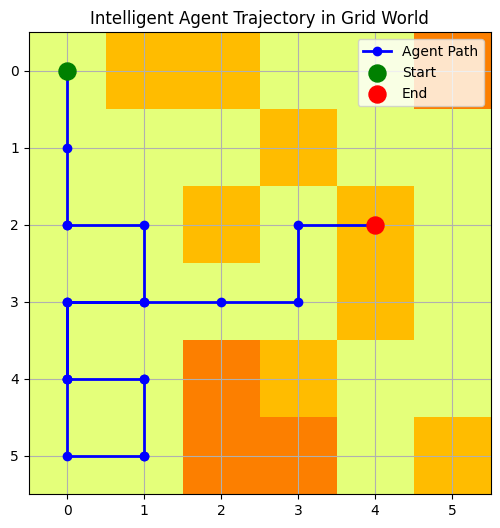

In [5]:
import matplotlib.pyplot as plt

def visualize_run():
    env = Environment(width=6, height=6, dirt_prob=0.3, obstacle_prob=0.15)
    agent = IntelligentAgent(start_pos=(0, 0))

    # Track path for plotting
    path = [agent.position]

    for _ in range(20):
        percept = env.get_percept(agent.position)
        action = agent.choose_action(percept, env)
        agent.execute_action(action, env)
        path.append(agent.position)

    # Plot setup
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(env.grid, cmap='Wistia', origin='upper')

    # Plot path
    path_r, path_c = zip(*path)
    ax.plot(path_c, path_r, marker='o', color='blue', linewidth=2, label='Agent Path')
    ax.scatter(path_c[0], path_r[0], color='green', s=150, label='Start', zorder=5)
    ax.scatter(path_c[-1], path_r[-1], color='red', s=150, label='End', zorder=5)

    ax.set_title("Intelligent Agent Trajectory in Grid World")
    ax.set_xticks(range(env.width))
    ax.set_yticks(range(env.height))
    ax.legend(loc='upper right')
    plt.grid(True)
    plt.show()

visualize_run()

#Approach 1: Add A* Pathfinding
A* allows the agent to calculate the shortest path to the nearest dirty cell while navigating around obstacles, replacing random exploration with optimal route planning.

In [6]:
import heapq

class AStarAgent(IntelligentAgent):
    """
    Extends IntelligentAgent with A* Search to navigate directly
    to dirt targets while bypassing obstacles.
    """
    def heuristic(self, a, b):
        """Manhattan distance heuristic."""
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def find_nearest_dirt(self, env):
        """Finds coordinates of all dirty cells currently in the grid."""
        dirty_cells = []
        for r in range(env.height):
            for c in range(env.width):
                if env.grid[r][c] == 1:
                    dirty_cells.append((r, c))
        return dirty_cells

    def a_star_search(self, start, target, env):
        """Computes the shortest path from start to target using A*."""
        frontier = []
        heapq.heappush(frontier, (0, start))
        came_from = {start: None}
        cost_so_far = {start: 0}

        while frontier:
            _, current = heapq.heappop(frontier)

            if current == target:
                break

            r, c = current
            neighbors = [(r-1, c), (r+1, c), (r, c-1), (r, c+1)]

            for next_pos in neighbors:
                if env.is_valid_position(next_pos):
                    new_cost = cost_so_far[current] + 1
                    if next_pos not in cost_so_far or new_cost < cost_so_far[next_pos]:
                        cost_so_far[next_pos] = new_cost
                        priority = new_cost + self.heuristic(target, next_pos)
                        heapq.heappush(frontier, (priority, next_pos))
                        came_from[next_pos] = current

        # Reconstruct path
        if target not in came_from:
            return []  # Target unreachable

        path = []
        curr = target
        while curr != start:
            path.append(curr)
            curr = came_from[curr]
        path.reverse()
        return path

    def plan_next_move(self, env):
        """Plans optimal move toward the closest dirty cell."""
        dirt_cells = self.find_nearest_dirt(env)
        if not dirt_cells:
            return 'STAY'

        # Find closest dirty cell by Manhattan distance
        closest_dirt = min(dirt_cells, key=lambda d: self.heuristic(self.position, d))
        path = self.a_star_search(self.position, closest_dirt, env)

        if not path:
            return 'STAY'

        next_cell = path[0]
        r, c = self.position
        nr, nc = next_cell

        if nr < r: return 'UP'
        if nr > r: return 'DOWN'
        if nc < c: return 'LEFT'
        if nc > c: return 'RIGHT'
        return 'STAY'

#Approach 2: Add Reinforcement Learning (Q-Learning)
Q-learning enables the agent to learn an optimal policy through trial-and-error rewards without knowing the environment structure in advance.

In [7]:
import numpy as np

class QLearningAgent:
    """
    Model-free Reinforcement Learning Agent using Q-learning.
    """
    def __init__(self, actions=['UP', 'DOWN', 'LEFT', 'RIGHT', 'CLEAN'],
                 alpha=0.1, gamma=0.9, epsilon=0.2):
        self.actions = actions
        self.alpha = alpha      # Learning rate
        self.gamma = gamma      # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = {}       # Maps state (pos_r, pos_c, is_dirty) -> action values
        self.score = 0
        self.position = (0, 0)

    def get_state(self, env):
        """Encodes agent state: (row, col, current_cell_is_dirty)."""
        is_dirty = 1 if env.get_percept(self.position) == 1 else 0
        return (self.position[0], self.position[1], is_dirty)

    def get_q_values(self, state):
        """Gets Q-values for a state, initializing to 0 if unseen."""
        if state not in self.q_table:
            self.q_table[state] = {action: 0.0 for action in self.actions}
        return self.q_table[state]

    def choose_action(self, state):
        """Epsilon-greedy action selection."""
        if random.random() < self.epsilon:
            return random.choice(self.actions)  # Explore

        q_vals = self.get_q_values(state)
        return max(q_vals, key=q_vals.get)       # Exploit best action

    def train_step(self, env):
        """Performs one step of Q-learning update."""
        state = self.get_state(env)
        action = self.choose_action(state)

        # Determine reward and next position
        reward = -1  # Step penalty
        next_pos = self.position

        if action == 'CLEAN':
            if env.clean_cell(self.position):
                reward = 20  # High reward for cleaning dirt
                self.score += 20
        else:
            r, c = self.position
            moves = {'UP': (r-1, c), 'DOWN': (r+1, c), 'LEFT': (r, c-1), 'RIGHT': (r, c+1)}
            target_pos = moves[action]

            if env.is_valid_position(target_pos):
                next_pos = target_pos
            else:
                reward = -5  # Penalty for hitting wall/obstacle

        self.position = next_pos
        next_state = self.get_state(env)

        # Q-value update rule: Q(s,a) = Q(s,a) + alpha * [r + gamma * max(Q(s',a')) - Q(s,a)]
        current_q = self.get_q_values(state)[action]
        max_next_q = max(self.get_q_values(next_state).values())

        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][action] = new_q

#Interactive Parameter Setup Cell
Copy this code into a Colab cell. Changing the values in the right-hand form pane (or running the cell) will update the underlying variables immediately.

In [8]:
# @title ⚙️ Simulation & Agent Configuration Forms { display-mode: "form" }

# @markdown ### 🌐 Environment Settings
GRID_WIDTH = 8 # @param {type:"slider", min:4, max:15, step:1}
GRID_HEIGHT = 8 # @param {type:"slider", min:4, max:15, step:1}
DIRT_DENSITY = 0.35 # @param {type:"slider", min:0.05, max:0.8, step:0.05}
OBSTACLE_DENSITY = 0.15 # @param {type:"slider", min:0.0, max:0.4, step:0.05}

# @markdown ### 🧠 Q-Learning Hyperparameters
LEARNING_RATE_ALPHA = 0.15 # @param {type:"number"}
DISCOUNT_FACTOR_GAMMA = 0.95 # @param {type:"number"}
EXPLORATION_EPSILON = 0.2 # @param {type:"slider", min:0.0, max:1.0, step:0.05}
TRAINING_EPISODES = 200 # @param {type:"integer"}

# @markdown ### 🕹️ Execution Controls
AGENT_TYPE = "Q-Learning" # @param ["Base Reflex", "A* Pathfinding", "Q-Learning"]
MAX_STEPS_PER_RUN = 30 # @param {type:"integer"}

print("Configured Parameters Successfully!")
print(f"Grid Dimensions : {GRID_WIDTH}x{GRID_HEIGHT}")
print(f"Selected Agent  : {AGENT_TYPE}")
print(f"Alpha / Epsilon  : {LEARNING_RATE_ALPHA} / {EXPLORATION_EPSILON}")

Configured Parameters Successfully!
Grid Dimensions : 8x8
Selected Agent  : Q-Learning
Alpha / Epsilon  : 0.15 / 0.2


#Dynamic Execution Pipeline
Run this cell after setting your parameters in the form above. It uses the dynamic form variables to configure the environment and agent execution automatically.

Training Q-Learning Agent over 200 episodes...


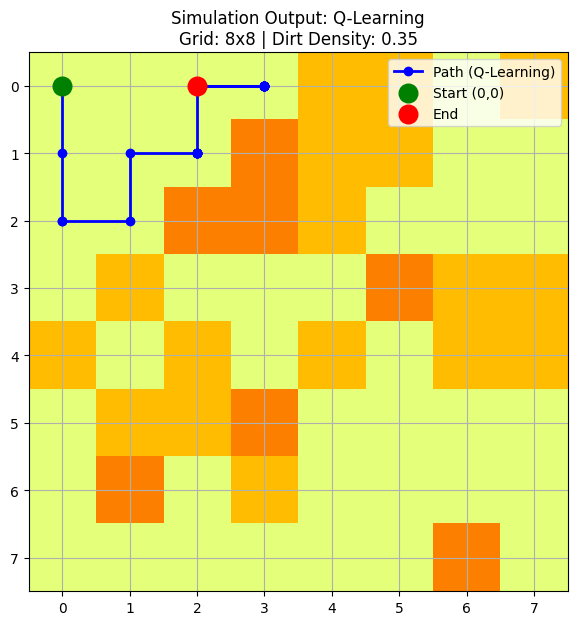

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt

# 1. Instantiate dynamic environment from form values
env = Environment(
    width=GRID_WIDTH,
    height=GRID_HEIGHT,
    dirt_prob=DIRT_DENSITY,
    obstacle_prob=OBSTACLE_DENSITY
)

# 2. Select and initialize agent based on form input
if AGENT_TYPE == "Base Reflex":
    agent = IntelligentAgent(start_pos=(0, 0))

elif AGENT_TYPE == "A* Pathfinding":
    agent = AStarAgent(start_pos=(0, 0))

elif AGENT_TYPE == "Q-Learning":
    agent = QLearningAgent(
        alpha=LEARNING_RATE_ALPHA,
        gamma=DISCOUNT_FACTOR_GAMMA,
        epsilon=EXPLORATION_EPSILON
    )
    # Train Q-agent briefly using configured episodes
    print(f"Training Q-Learning Agent over {TRAINING_EPISODES} episodes...")
    for episode in range(TRAINING_EPISODES):
        train_env = Environment(GRID_WIDTH, GRID_HEIGHT, DIRT_DENSITY, OBSTACLE_DENSITY)
        agent.position = (0, 0)
        for _ in range(MAX_STEPS_PER_RUN):
            agent.train_step(train_env)

    # Reset for evaluation run
    agent.position = (0, 0)
    agent.epsilon = 0.0  # Exploit learned policy during test run

# 3. Execute step simulation
path = [agent.position]
for step in range(MAX_STEPS_PER_RUN):
    percept = env.get_percept(agent.position)

    if AGENT_TYPE == "A* Pathfinding":
        if percept == 1:
            action = 'CLEAN'
        else:
            action = agent.plan_next_move(env)
        agent.execute_action(action, env)

    elif AGENT_TYPE == "Q-Learning":
        agent.train_step(env)

    else:  # Base Reflex
        action = agent.choose_action(percept, env)
        agent.execute_action(action, env)

    path.append(agent.position)

# 4. Render output grid map
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(env.grid, cmap='Wistia', origin='upper')

path_r, path_c = zip(*path)
ax.plot(path_c, path_r, marker='o', color='blue', linewidth=2, label=f'Path ({AGENT_TYPE})')
ax.scatter(path_c[0], path_r[0], color='green', s=180, label='Start (0,0)', zorder=5)
ax.scatter(path_c[-1], path_r[-1], color='red', s=180, label='End', zorder=5)

ax.set_title(f"Simulation Output: {AGENT_TYPE}\nGrid: {GRID_WIDTH}x{GRID_HEIGHT} | Dirt Density: {DIRT_DENSITY}")
ax.set_xticks(range(env.width))
ax.set_yticks(range(env.height))
ax.legend(loc='upper right')
plt.grid(True)
plt.show()

## Parameter Experimentation & Comparative Analysis
Testing different grid sizes, obstacle densities, and agent strategies.

#Base Reflex  Agent
Local, Short-Sighted Vision: The reflex agent only senses the square it is currently sitting on. It has no awareness of where dirt is located across the map.   
Random Local Decisions: When not on dirt, it simply picks an adjacent open cell (prioritizing unvisited ones randomly).  

In [11]:
#Base Reflex -Uses a greedy approach to find the next obstacle
import copy

# 1. Setup shared environment and agents
env = Environment(width=8, height=8, dirt_prob=0.35, obstacle_prob=0.2)
initial_grid = copy.deepcopy(env.grid)

agents = {
    "Base Reflex": IntelligentAgent(),
    "A* Search": AStarAgent()
}

# 2. Run both agents on identical maps for 30 steps
for name, agent in agents.items():
    env.grid = copy.deepcopy(initial_grid)
    for _ in range(30):
        percept = env.get_percept(agent.position)
        action = 'CLEAN' if percept == 1 else (agent.plan_next_move(env) if hasattr(agent, 'plan_next_move') else agent.choose_action(percept, env))
        agent.execute_action(action, env)
    print(f"{name:12s} -> Score: {agent.score} | Energy Remaining: {agent.energy}")

Action: MOVE RIGHT -> (0, 1)
Action: MOVE RIGHT -> (0, 2)
Action: MOVE DOWN -> (1, 2)
Action: CLEAN | Score +10 | Position: (1, 2)
Action: MOVE DOWN -> (2, 2)
Action: MOVE DOWN -> (3, 2)
Action: CLEAN | Score +10 | Position: (3, 2)
Action: MOVE DOWN -> (4, 2)
Action: MOVE DOWN -> (5, 2)
Action: CLEAN | Score +10 | Position: (5, 2)
Action: MOVE RIGHT -> (5, 3)
Action: CLEAN | Score +10 | Position: (5, 3)
Action: MOVE RIGHT -> (5, 4)
Action: CLEAN | Score +10 | Position: (5, 4)
Action: MOVE UP -> (4, 4)
Action: CLEAN | Score +10 | Position: (4, 4)
Action: MOVE UP -> (3, 4)
Action: MOVE LEFT -> (3, 3)
Action: MOVE UP -> (2, 3)
Action: MOVE RIGHT -> (2, 4)
Action: CLEAN | Score +10 | Position: (2, 4)
Action: MOVE RIGHT -> (2, 5)
Action: MOVE RIGHT -> (2, 6)
Action: MOVE RIGHT -> (2, 7)
Action: CLEAN | Score +10 | Position: (2, 7)
Action: MOVE DOWN -> (3, 7)
Action: CLEAN | Score +10 | Position: (3, 7)
Action: MOVE DOWN -> (4, 7)
Action: CLEAN | Score +10 | Position: (4, 7)
Action: MOVE LEF

Action: MOVE DOWN -> (1, 0)
Action: CLEAN | Score +10 | Position: (1, 0)
Action: MOVE DOWN -> (2, 0)
Action: CLEAN | Score +10 | Position: (2, 0)
Action: MOVE DOWN -> (3, 0)
Action: CLEAN | Score +10 | Position: (3, 0)
Action: MOVE RIGHT -> (3, 1)
Action: CLEAN | Score +10 | Position: (3, 1)
Action: MOVE UP -> (2, 1)
Action: MOVE UP -> (1, 1)
Action: CLEAN | Score +10 | Position: (1, 1)
Action: MOVE UP -> (0, 1)
Action: MOVE DOWN -> (1, 1)
Action: MOVE LEFT -> (1, 0)
Action: MOVE RIGHT -> (1, 1)
Action: MOVE RIGHT -> (1, 2)
Action: CLEAN | Score +10 | Position: (1, 2)
Action: MOVE UP -> (0, 2)
Action: MOVE RIGHT -> (0, 3)
Action: CLEAN | Score +10 | Position: (0, 3)
Action: MOVE RIGHT -> (0, 4)
Action: CLEAN | Score +10 | Position: (0, 4)
Action: MOVE DOWN -> (1, 4)
Action: MOVE RIGHT -> (1, 5)
Action: MOVE UP -> (0, 5)
Action: CLEAN | Score +10 | Position: (0, 5)
Action: MOVE RIGHT -> (0, 6)
Action: MOVE DOWN -> (1, 6)
Action: CLEAN | Score +10 | Position: (1, 6)
Action: MOVE DOWN -> 

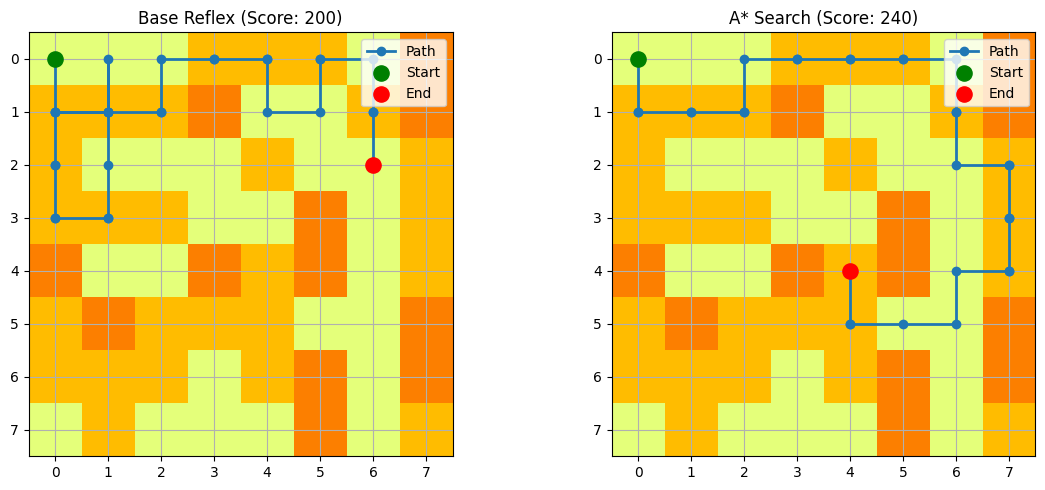

In [12]:
import matplotlib.pyplot as plt

# 1. Run and record paths for both agents
paths = {}
for name, agent in agents.items():
    env.grid = copy.deepcopy(initial_grid)
    agent.position = (0, 0)
    paths[name] = [agent.position]

    for _ in range(30):
        percept = env.get_percept(agent.position)
        action = 'CLEAN' if percept == 1 else (agent.plan_next_move(env) if hasattr(agent, 'plan_next_move') else agent.choose_action(percept, env))
        agent.execute_action(action, env)
        paths[name].append(agent.position)

# 2. Plot side-by-side trajectories
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, path) in zip(axes, paths.items()):
    ax.imshow(initial_grid, cmap='Wistia', origin='upper')
    r, c = zip(*path)
    ax.plot(c, r, marker='o', linewidth=2, label='Path')
    ax.scatter(c[0], r[0], color='green', s=120, label='Start', zorder=5)
    ax.scatter(c[-1], r[-1], color='red', s=120, label='End', zorder=5)
    ax.set_title(f"{name} (Score: {agents[name].score})")
    ax.set_xticks(range(env.width))
    ax.set_yticks(range(env.height))
    ax.grid(True)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Change the Mahattan Distance Calculation to Euclidean

In [17]:
import copy, math

# 1. Setup shared environment and agents
env = Environment(width=8, height=8, dirt_prob=0.35, obstacle_prob=0.2)
shared_grid = copy.deepcopy(env.grid)

agents = {"Manhattan A*": AStarAgent(), "Euclidean A*": AStarAgent()}
# Override heuristic on the second agent using Euclidean straight-line distance
agents["Euclidean A*"].heuristic = lambda a, b: math.hypot(a[0] - b[0], a[1] - b[1])

# 2. Run simulation loop for both
for name, agent in agents.items():
    env.grid = copy.deepcopy(shared_grid)
    for _ in range(30):
        percept = env.get_percept(agent.position)
        action = 'CLEAN' if percept == 1 else agent.plan_next_move(env)
        agent.execute_action(action, env)


    print(f"{name} -> Score: {agent.score} | Visited Cells: {len(agent.visited_cells)}")

Action: MOVE DOWN -> (1, 0)
Action: CLEAN | Score +10 | Position: (1, 0)
Action: MOVE DOWN -> (2, 0)
Action: CLEAN | Score +10 | Position: (2, 0)
Action: MOVE DOWN -> (3, 0)
Action: CLEAN | Score +10 | Position: (3, 0)
Action: MOVE UP -> (2, 0)
Action: MOVE UP -> (1, 0)
Action: MOVE UP -> (0, 0)
Action: MOVE RIGHT -> (0, 1)
Action: MOVE RIGHT -> (0, 2)
Action: MOVE RIGHT -> (0, 3)
Action: CLEAN | Score +10 | Position: (0, 3)
Action: MOVE RIGHT -> (0, 4)
Action: CLEAN | Score +10 | Position: (0, 4)
Action: MOVE LEFT -> (0, 3)
Action: MOVE DOWN -> (1, 3)
Action: CLEAN | Score +10 | Position: (1, 3)
Action: MOVE LEFT -> (1, 2)
Action: MOVE DOWN -> (2, 2)
Action: CLEAN | Score +10 | Position: (2, 2)
Action: MOVE RIGHT -> (2, 3)
Action: MOVE RIGHT -> (2, 4)
Action: CLEAN | Score +10 | Position: (2, 4)
Action: MOVE RIGHT -> (2, 5)
Action: MOVE RIGHT -> (2, 6)
Action: CLEAN | Score +10 | Position: (2, 6)
Action: MOVE DOWN -> (3, 6)
Action: CLEAN | Score +10 | Position: (3, 6)
Action: MOVE LEF